# Appendix C2.5 — Shot Noise Analysis: FidelityQuantumKernel vs FidelityStatevectorKernel

**Câu hỏi nghiên cứu:**  
Shot noise từ việc ước lượng kernel bằng sampling (FidelityQuantumKernel) ảnh hưởng bao nhiêu đến hiệu năng QSVM so với kernel chính xác (FidelityStatevectorKernel)?

**Vị trí trong khung nghiên cứu:**  
- C2 xác lập rằng ZZFeatureMap phù hợp với dữ liệu IDS thông qua cơ chế entanglement.  
- C3/C4 sử dụng FidelityStatevectorKernel (exact, noiseless) như nền tảng so sánh.  
- **C2.5 định lượng khoảng cách giữa statevector exact/noiseless reference và finite-shot sampling proxy** — một contribution độc lập không làm nhiễu C3/C4.

**Giá trị khoa học:**  
1. **Quantify shot noise gap:** Đo chênh lệch F1-macro, kernel matrix similarity (Frobenius distance, cosine sim) giữa hai backend.
2. **Shot convergence analysis:** Tìm ngưỡng shots tối thiểu để FidelityQuantumKernel hội tụ về statevector baseline.
3. **Kernel matrix variance:** Phân tích variance của K(x,z) theo số shots — minh chứng định lượng cho ảnh hưởng finite-shot sampling.
4. **Decision boundary stability:** So sánh số support vectors, margin, và phân phối decision scores.
5. **Finite-shot feasibility proxy:** Cung cấp khuyến nghị shots thực tế dưới giả định chỉ có sampling noise.

**Pipeline:** `Cleaned.csv` → `selector.joblib` → `pca.joblib` → `scaler.joblib` → QSVM (2 backends)

**Thiết kế thực nghiệm:**
- Train/Test target size: **100/100**; caption và báo cáo dùng shape thực tế sau khi load CSV.
- ZZFeatureMap(reps=2, entanglement='full', n_qubits=4) — giống C3
- FidelityStatevectorKernel: exact (baseline lý thuyết)
- FidelityQuantumKernel: shots ∈ {128, 512, 2048, 8192}
- 3 random seeds mỗi cấu hình shots → bootstrap statistics gọn nhưng vẫn đo được variance

**Thứ tự thực thi:**
1. Config & Imports
2. Load Transformers & Pipeline
3. Load Dataset (target n=100; actual shape reported)
4. Baseline: FidelityStatevectorKernel (exact)
5. Shot-based: FidelityQuantumKernel × shots grid × seeds
6. Kernel Matrix Similarity Analysis
7. Classification Performance vs Shots
8. Kernel Variance Analysis (per-entry variance)
9. Decision Score Distribution
10. Visualization tổng hợp (4 figures)
11. Summary & Finite-Shot Feasibility Recommendation


## 1. Config & Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os, time, json, warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, classification_report

# ── Qiskit imports ─────────────────────────────────────────────────────────────
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import StatevectorSampler as Sampler             # shot-based (Sampler V2)
from qiskit_machine_learning.kernels import (
    FidelityStatevectorKernel,   # exact statevector — baseline
    FidelityQuantumKernel,       # shot-based       — finite-shot proxy
)
from qiskit_algorithms.state_fidelities import ComputeUncompute

import qiskit, qiskit_machine_learning
print(f'Qiskit              : {qiskit.__version__}')
print(f'Qiskit ML           : {qiskit_machine_learning.__version__}')

# ── Cấu hình chính ─────────────────────────────────────────────────────────────
RANDOM_STATE  = 42
N_QUBITS      = 4           # khớp với pca_4components.joblib
ANGLE_MAX     = np.pi       # MinMaxScaler range [0, pi]

# ── ZZFeatureMap — giữ nguyên như C3 (fair comparison) ────────────────────────
REPS          = 2
ENTANGLEMENT  = 'full'
C_SVM         = 1.0         # C_QSVM từ C3

# ── Shot grid cho FidelityQuantumKernel ───────────────────────────────────────
# Sampling error is expected to decrease as shots increase; 1/sqrt(shots) is a useful reference trend.
# For epsilon = 0.01 (1% precision), a rough binomial reference is shots ~ 10,000.
SHOTS_GRID    = [128, 512, 2048, 8192]

# ── Bootstrap seeds — đánh giá variance của shot noise ────────────────────────
# Mỗi seed → Sampler khác nhau → kernel matrix khác nhau do sampling randomness
# 3 seeds giữ được ước lượng variance cơ bản, giảm runtime đáng kể.
N_SEEDS       = 3
SEED_LIST     = [42, 123, 456]

# ── Train/Test target size — actual loaded shape is reported after reading CSV ──
TRAIN_SIZE    = 100
TEST_SIZE     = 100

LABEL_COLS    = ['label', 'label_binary', 'label_multiclass', 'attack_category']

# ── Đường dẫn ──────────────────────────────────────────────────────────────────
DATA_DIR      = '../data/processed_data'
MODELS_DIR    = '../models'
CACHE_DIR     = f'{MODELS_DIR}/qsvm_cache/results_c25_shotanalysis'
os.makedirs(CACHE_DIR, exist_ok=True)
OUTPUT_DIR    = '../outputs/c25'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── CONFIG_TAG cho cache ────────────────────────────────────────────────────────
CONFIG_TAG = (
    f'r{REPS}_{ENTANGLEMENT}'
    f'_c{C_SVM}'
    f'_n{TRAIN_SIZE}_t{TEST_SIZE}'
    f'_seeds{N_SEEDS}'
)

def make_sampler(shots, seed):
    """Create a Sampler V2 instance compatible with the installed Qiskit."""
    return Sampler(default_shots=int(shots), seed=int(seed))

np.random.seed(RANDOM_STATE)
print(f'\n=== C2.5 Shot Noise Analysis [CONFIG_TAG={CONFIG_TAG}] ===')
print(f'  N_QUBITS      : {N_QUBITS}')
print(f'  REPS          : {REPS}')
print(f'  ENTANGLEMENT  : {ENTANGLEMENT}')
print(f'  C_SVM         : {C_SVM}')
print(f'  SHOTS_GRID    : {SHOTS_GRID}')
print(f'  N_SEEDS       : {N_SEEDS}')
print(f'  TRAIN_SIZE    : {TRAIN_SIZE}')
print(f'  TEST_SIZE     : {TEST_SIZE}')
print(f'  CACHE_DIR     : {CACHE_DIR}')
print(f'  OUTPUT_DIR    : {OUTPUT_DIR}')


Qiskit              : 2.3.0
Qiskit ML           : 0.9.0

=== C2.5 Shot Noise Analysis [CONFIG_TAG=r2_full_c1.0_n100_t100_seeds3] ===
  N_QUBITS      : 4
  REPS          : 2
  ENTANGLEMENT  : full
  C_SVM         : 1.0
  SHOTS_GRID    : [128, 512, 2048, 8192]
  N_SEEDS       : 3
  TRAIN_SIZE    : 100
  TEST_SIZE     : 100
  CACHE_DIR     : ../models/qsvm_cache/results_c25_shotanalysis
  OUTPUT_DIR    : ../outputs/c25


## 2. Load Transformers & Transform Pipeline


In [2]:
# Load 3 transformer đã fit trên full train — KHÔNG fit lại (zero-leakage contract)
selector = joblib.load(f'{MODELS_DIR}/feature_selector_k20.joblib')
pca      = joblib.load(f'{MODELS_DIR}/pca_4components.joblib')
scaler   = joblib.load(f'{MODELS_DIR}/scaler_minmax_pi.joblib')

print(f'SelectKBest : k={selector.k}, score_func={selector.score_func.__name__}')
print(f'PCA         : n_components={pca.n_components_}, '
      f'variance={pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'Scaler      : range=[{scaler.feature_range[0]:.4f}, {scaler.feature_range[1]:.4f}]')

PC_LABELS = [f'PC{i+1}' for i in range(N_QUBITS)]


def transform_pipeline(df, feature_cols):
    """Cleaned CSV -> angle-encoded numpy array [0, pi]. KHÔNG fit lại."""
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    X_pca = pca.transform(X_sel)
    X_ang = np.clip(scaler.transform(X_pca), 0, ANGLE_MAX)
    return X_ang


SelectKBest : k=20, score_func=f_classif
PCA         : n_components=4, variance=86.62%
Scaler      : range=[0.0000, 3.1416]


## 3. Load Dataset (Target n=100; Actual Shape Reported)


In [3]:
feature_cols = None

# ── Load train ─────────────────────────────────────────────────────────────────
train_path = f'{DATA_DIR}/NSL_KDD_Train_Sample{TRAIN_SIZE}.csv'
if not os.path.exists(train_path):
    raise FileNotFoundError(
        f'[MISSING] {train_path}\n'
        f'Hãy tạo file này bằng cách stratified-sample {TRAIN_SIZE} rows từ KDDTrain+.txt '
        f'(cùng script tạo sample cho C3).'
    )

df_train     = pd.read_csv(train_path)
feature_cols = [c for c in df_train.columns if c not in LABEL_COLS]
X_train      = transform_pipeline(df_train, feature_cols)
y_train      = df_train['label_binary'].to_numpy(dtype=np.int64)
print(f'Train : {X_train.shape} | class dist={np.bincount(y_train)} | '
      f'Normal={np.bincount(y_train)[0]}, Attack={np.bincount(y_train)[1]}')

# ── Load test ──────────────────────────────────────────────────────────────────
test_path = f'{DATA_DIR}/NSL_KDD_Test_Sample{TEST_SIZE}.csv'
if not os.path.exists(test_path):
    raise FileNotFoundError(
        f'[MISSING] {test_path}\n'
        f'Hãy tạo file này bằng cách stratified-sample {TEST_SIZE} rows từ KDDTest+.txt.'
    )

df_test      = pd.read_csv(test_path)
X_test       = transform_pipeline(df_test, feature_cols)
y_test       = df_test['label_binary'].to_numpy(dtype=np.int64)
print(f'Test  : {X_test.shape}  | class dist={np.bincount(y_test)} | '
      f'Normal={np.bincount(y_test)[0]}, Attack={np.bincount(y_test)[1]}')

print(f'\nFeature space range: [{X_train.min():.4f}, {X_train.max():.4f}] '
      f'(expected [0, π={ANGLE_MAX:.4f}])')
print(f'feature_cols: {len(feature_cols)} cột')

# ── Actual loaded sizes (CSV may contain fewer rows than target size) ─────────
N_TRAIN_ACTUAL = X_train.shape[0]
N_TEST_ACTUAL  = X_test.shape[0]
print(f'Actual loaded sizes: train={N_TRAIN_ACTUAL}, test={N_TEST_ACTUAL} '
      f'(target config: {TRAIN_SIZE}/{TEST_SIZE})')
print(f'CONFIG_TAG unchanged for cache compatibility: {CONFIG_TAG}')


Train : (100, 4) | class dist=[48 52] | Normal=48, Attack=52
Test  : (100, 4)  | class dist=[44 56] | Normal=44, Attack=56

Feature space range: [0.0314, 3.1416] (expected [0, π=3.1416])
feature_cols: 122 cột
Actual loaded sizes: train=100, test=100 (target config: 100/100)
CONFIG_TAG unchanged for cache compatibility: r2_full_c1.0_n100_t100_seeds3


## 4. Helper Functions


In [4]:
def build_feature_map():
    """ZZFeatureMap cố định — giữ nguyên như C3 để fair comparison."""
    return ZZFeatureMap(
        feature_dimension=N_QUBITS,
        reps=REPS,
        entanglement=ENTANGLEMENT,
    )


def train_and_eval(K_train, K_test, y_train, y_test, C=C_SVM):
    """
    Train SVC(kernel='precomputed') từ kernel matrix đã tính sẵn.
    Trả về dict: f1_macro, accuracy, n_sv, decision_scores_test.
    """
    clf = SVC(C=C, kernel='precomputed', random_state=RANDOM_STATE, probability=False)
    clf.fit(K_train, y_train)
    y_pred = clf.predict(K_test)
    scores = clf.decision_function(K_test)
    return {
        'f1_macro'  : f1_score(y_test, y_pred, average='macro'),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'n_sv'      : clf.n_support_.sum(),
        'dec_scores': scores,
        'y_pred'    : y_pred,
    }


def frobenius_similarity(K1, K2):
    """
    Cosine similarity giữa hai kernel matrix (Frobenius inner-product normalized).
    = <K1, K2>_F / (||K1||_F * ||K2||_F)
    Giá trị 1.0 = identical, 0.0 = orthogonal.
    """
    dot = np.sum(K1 * K2)
    norm1 = np.linalg.norm(K1, 'fro')
    norm2 = np.linalg.norm(K2, 'fro')
    return float(dot / (norm1 * norm2 + 1e-12))


def frobenius_distance(K1, K2):
    """||K1 - K2||_F / n^2 — normalized Frobenius distance."""
    n = K1.shape[0]
    return float(np.linalg.norm(K1 - K2, 'fro')) / (n * n)


def kta(K, y):
    """
    Kernel Target Alignment (Cristianini et al., 2002).
    KTA = <K, yy^T>_F / (||K||_F * ||yy^T||_F)
    """
    y_col = y.reshape(-1, 1).astype(float) * 2 - 1  # {0,1} → {-1,+1}
    yyt   = y_col @ y_col.T
    return float(np.sum(K * yyt) / (
        np.linalg.norm(K, 'fro') * np.linalg.norm(yyt, 'fro') + 1e-12
    ))


def cache_path(tag):
    return os.path.join(CACHE_DIR, f'{tag}.npz')


print('Helper functions loaded.')


Helper functions loaded.


## 5. Baseline: FidelityStatevectorKernel (Exact / Noiseless)

FidelityStatevectorKernel tính K(x,z) = |⟨ϕ(x)|ϕ(z)⟩|² bằng inner-product trực tiếp trên statevector —  
kết quả **exact/noiseless**, không có sampling variance. Đây là **mốc tham chiếu exact cho kernel geometry**, không phải upper bound bắt buộc của F1/accuracy; shot noise đôi khi có thể làm F1 tăng nhẹ như một dạng stochastic perturbation.


In [5]:
sv_cache_train = cache_path(f'sv_train_{CONFIG_TAG}')
sv_cache_test  = cache_path(f'sv_test_{CONFIG_TAG}')

if os.path.exists(sv_cache_train) and os.path.exists(sv_cache_test):
    K_sv_train = np.load(sv_cache_train)['K']
    K_sv_test  = np.load(sv_cache_test)['K']
    print(f'[CACHE HIT] Statevector kernel loaded from cache.')
else:
    feature_map = build_feature_map()
    sv_kernel   = FidelityStatevectorKernel(
        feature_map=feature_map,
        # cache_statevectors=True  # uncomment nếu version hỗ trợ
    )
    print('Computing FidelityStatevectorKernel (exact)...')
    t0 = time.time()
    K_sv_train = sv_kernel.evaluate(X_train)
    t_train = time.time() - t0

    t0 = time.time()
    K_sv_test  = sv_kernel.evaluate(X_test, X_train)
    t_test = time.time() - t0

    np.savez_compressed(sv_cache_train, K=K_sv_train)
    np.savez_compressed(sv_cache_test,  K=K_sv_test)
    print(f'  Train kernel ({K_sv_train.shape[0]}×{K_sv_train.shape[1]}): {t_train:.1f}s')
    print(f'  Test  kernel ({K_sv_test.shape[0]}×{K_sv_test.shape[1]}):  {t_test:.1f}s')
    print(f'[CACHE SAVED] Statevector kernel.')

# ── Evaluate baseline ──────────────────────────────────────────────────────────
sv_results = train_and_eval(K_sv_train, K_sv_test, y_train, y_test)

# ── KTA của statevector kernel ─────────────────────────────────────────────────
sv_kta = kta(K_sv_train, y_train)

print(f'\n=== BASELINE: FidelityStatevectorKernel (Exact) ===')
print(f'  F1-macro  : {sv_results["f1_macro"]:.4f}')
print(f'  Accuracy  : {sv_results["accuracy"]:.4f}')
print(f'  N_SV      : {sv_results["n_sv"]}')
print(f'  KTA       : {sv_kta:.4f}')
print(f'  K_train stats: min={K_sv_train.min():.4f}, max={K_sv_train.max():.4f}, '
      f'mean={K_sv_train.mean():.4f}')
print(f'  (Variance của K_train entries = 0.0 — deterministic)')


Computing FidelityStatevectorKernel (exact)...
  Train kernel (100×100): 0.3s
  Test  kernel (100×100):  0.4s
[CACHE SAVED] Statevector kernel.

=== BASELINE: FidelityStatevectorKernel (Exact) ===
  F1-macro  : 0.7796
  Accuracy  : 0.7800
  N_SV      : 60
  KTA       : 0.1861
  K_train stats: min=0.0000, max=1.0000, mean=0.1400
  (Variance của K_train entries = 0.0 — deterministic)


## 6. Shot-based: FidelityQuantumKernel × Shots Grid × Seeds

FidelityQuantumKernel ước lượng K(x,z) bằng cách đo xác suất đầu ra của mạch  
`U†(x)·U(z)|0⟩` → số lần đo `|0...0⟩` / tổng shots.  
**Shot noise** → K_estimated(x,z) = K_exact(x,z) + ε, với ε ~ N(0, σ²/shots).  
Với mỗi cấu hình (shots, seed), ta train một QSVM riêng và đo khoảng cách kernel matrix.


In [6]:
# ── Main experiment loop ────────────────────────────────────────────────────────
# results[shots] = list of dicts (one per seed)
shot_results = {}  # shots → list[dict]

total_experiments = len(SHOTS_GRID) * N_SEEDS
exp_count = 0

# ── NOTE về seed reproducibility ────────────────────────────────────────────────
# StatevectorSampler là Sampler V2: truyền shots/seed bằng default_shots và seed,
# không dùng options dict như Sampler V1/Aer cũ.
# Kiểm tra: nếu N_SEEDS seeds cho std=0, seed chưa có tác dụng → debug bên dưới.
# ───────────────────────────────────────────────────────────────────────────────

for shots in SHOTS_GRID:
    shot_results[shots] = []
    
    for seed_idx, seed in enumerate(SEED_LIST[:N_SEEDS]):
        exp_count += 1
        tag_train = f'shot{shots}_seed{seed}_train_{CONFIG_TAG}'
        tag_test  = f'shot{shots}_seed{seed}_test_{CONFIG_TAG}'
        cp_train  = cache_path(tag_train)
        cp_test   = cache_path(tag_test)
        
        if os.path.exists(cp_train) and os.path.exists(cp_test):
            K_shot_train = np.load(cp_train)['K']
            K_shot_test  = np.load(cp_test)['K']
            elapsed = np.nan   # thời gian không lưu trong cache run
            from_cache = True
        else:
            # ── Build FidelityQuantumKernel với Sampler có seed cố định ──────
            sampler     = make_sampler(shots=shots, seed=seed)
            fidelity    = ComputeUncompute(sampler=sampler, shots=shots)
            feature_map = build_feature_map()
            qk = FidelityQuantumKernel(
                feature_map=feature_map,
                fidelity=fidelity,
            )
            t0 = time.time()
            K_shot_train = qk.evaluate(X_train)
            K_shot_test  = qk.evaluate(X_test, X_train)
            elapsed = time.time() - t0   # [BUG FIX] lưu wall-clock time
            np.savez_compressed(cp_train, K=K_shot_train)
            np.savez_compressed(cp_test,  K=K_shot_test)
            from_cache = False
        
        # ── [NEW] Kiểm tra PSD của kernel matrix ──────────────────────────────
        # Shot noise có thể khiến K_shot_train không PSD → SVC không ổn định
        min_eigenval = float(np.linalg.eigvalsh(K_shot_train).min())
        if min_eigenval < -1e-6:
            print(f'  [WARNING] K_train not PSD: min_eigenval={min_eigenval:.6f} '
                  f'(shots={shots}, seed={seed}) — SVC may be unstable')
        
        # ── Classification ────────────────────────────────────────────────────
        res = train_and_eval(K_shot_train, K_shot_test, y_train, y_test)
        
        # ── Kernel similarity vs statevector ──────────────────────────────────
        fro_sim  = frobenius_similarity(K_shot_train, K_sv_train)
        fro_dist = frobenius_distance(K_shot_train, K_sv_train)
        test_fro_sim  = frobenius_similarity(K_shot_test, K_sv_test)
        test_fro_dist = frobenius_distance(K_shot_test, K_sv_test)
        shot_kta = kta(K_shot_train, y_train)
        
        # ── Per-entry error vs statevector for train and test kernels ─────────
        entry_mae   = float(np.mean(np.abs(K_shot_train - K_sv_train)))
        entry_rmse  = float(np.sqrt(np.mean((K_shot_train - K_sv_train)**2)))
        test_entry_mae  = float(np.mean(np.abs(K_shot_test - K_sv_test)))
        test_entry_rmse = float(np.sqrt(np.mean((K_shot_test - K_sv_test)**2)))
        
        shot_results[shots].append({
            'shots'       : shots,
            'seed'        : seed,
            'f1_macro'    : res['f1_macro'],
            'accuracy'    : res['accuracy'],
            'n_sv'        : res['n_sv'],
            'fro_sim'        : fro_sim,
            'fro_dist'       : fro_dist,
            'test_fro_sim'   : test_fro_sim,
            'test_fro_dist'  : test_fro_dist,
            'entry_mae'      : entry_mae,
            'entry_rmse'     : entry_rmse,
            'test_entry_mae' : test_entry_mae,
            'test_entry_rmse': test_entry_rmse,
            'kta'         : shot_kta,
            'dec_scores'  : res['dec_scores'].tolist(),
            'elapsed_s'   : elapsed,         # [BUG FIX] wall-clock time (nan if cache)
            'min_eigenval': min_eigenval,    # [NEW] PSD check
            'from_cache'  : from_cache,
        })
        
        cache_flag = '[cache]' if from_cache else f'[computed {elapsed:.0f}s]'
        print(f'[{exp_count:>3}/{total_experiments}] shots={shots:5d} seed={seed} '
              f'F1={res["f1_macro"]:.4f} '
              f'FroSim(train/test)={fro_sim:.4f}/{test_fro_sim:.4f} '
              f'MAE(train/test)={entry_mae:.5f}/{test_entry_mae:.5f} '
              f'minEig={min_eigenval:+.5f} {cache_flag}')

print('\n[DONE] All shot experiments completed.')
print(f'NOTE: \'elapsed_s\' = nan for cache hits. Re-run without cache to get timing data.')


[  1/12] shots=  128 seed=42 F1=0.7792 FroSim(train/test)=0.9987/0.9982 MAE(train/test)=0.01101/0.01107 minEig=-0.00000 [computed 72s]
[  2/12] shots=  128 seed=123 F1=0.7993 FroSim(train/test)=0.9979/0.9971 MAE(train/test)=0.01315/0.01349 minEig=-0.00000 [computed 87s]
[  3/12] shots=  128 seed=456 F1=0.7890 FroSim(train/test)=0.9946/0.9931 MAE(train/test)=0.02139/0.02146 minEig=-0.00000 [computed 86s]
[  4/12] shots=  512 seed=42 F1=0.7596 FroSim(train/test)=0.9991/0.9988 MAE(train/test)=0.00949/0.00958 minEig=-0.00000 [computed 90s]
[  5/12] shots=  512 seed=123 F1=0.7698 FroSim(train/test)=0.9996/0.9995 MAE(train/test)=0.00584/0.00581 minEig=-0.00000 [computed 81s]
[  6/12] shots=  512 seed=456 F1=0.7890 FroSim(train/test)=0.9988/0.9985 MAE(train/test)=0.00927/0.00922 minEig=-0.00000 [computed 82s]
[  7/12] shots= 2048 seed=42 F1=0.7596 FroSim(train/test)=0.9999/0.9998 MAE(train/test)=0.00356/0.00350 minEig=-0.00000 [computed 119s]
[  8/12] shots= 2048 seed=123 F1=0.7698 FroSim(tra

## 7. Aggregation & Summary Statistics


In [7]:
# ── Aggregate results → DataFrame ──────────────────────────────────────────────
rows = []
for shots, seed_list in shot_results.items():
    for r in seed_list:
        rows.append({k: v for k, v in r.items() if k != 'dec_scores'})
df_results = pd.DataFrame(rows)

# ── Per-shots statistics ───────────────────────────────────────────────────────
agg_cols = ['f1_macro', 'accuracy', 'n_sv',
            'fro_sim', 'fro_dist', 'test_fro_sim', 'test_fro_dist',
            'entry_mae', 'entry_rmse', 'test_entry_mae', 'test_entry_rmse',
            'kta', 'elapsed_s', 'min_eigenval']  # thêm train/test kernel error + timing + PSD
df_agg   = df_results.groupby('shots')[agg_cols].agg(['mean', 'std']).round(5)

# ── Flatten MultiIndex columns ─────────────────────────────────────────────────
df_agg.columns = ['_'.join(c) for c in df_agg.columns]
df_agg = df_agg.reset_index()

# ── Add statevector baseline as reference row ──────────────────────────────────
sv_row = {
    'shots'           : np.inf,
    'f1_macro_mean'   : sv_results['f1_macro'],
    'f1_macro_std'    : 0.0,
    'accuracy_mean'   : sv_results['accuracy'],
    'accuracy_std'    : 0.0,
    'n_sv_mean'       : sv_results['n_sv'],
    'n_sv_std'        : 0.0,
    'fro_sim_mean'    : 1.0,
    'fro_sim_std'     : 0.0,
    'fro_dist_mean'   : 0.0,
    'fro_dist_std'    : 0.0,
    'test_fro_sim_mean' : 1.0,
    'test_fro_sim_std'  : 0.0,
    'test_fro_dist_mean': 0.0,
    'test_fro_dist_std' : 0.0,
    'entry_mae_mean'  : 0.0,
    'entry_mae_std'   : 0.0,
    'entry_rmse_mean' : 0.0,
    'entry_rmse_std'  : 0.0,
    'test_entry_mae_mean' : 0.0,
    'test_entry_mae_std'  : 0.0,
    'test_entry_rmse_mean': 0.0,
    'test_entry_rmse_std' : 0.0,
    'kta_mean'        : sv_kta,
    'kta_std'         : 0.0,
}
df_agg_display = pd.concat([
    df_agg,
    pd.DataFrame([sv_row])
], ignore_index=True)

print('=== C2.5 Aggregated Results (mean ± std over seeds) ===')
print(f'\nStatevector Baseline:')
print(f'  F1-macro = {sv_results["f1_macro"]:.4f}  |  Accuracy = {sv_results["accuracy"]:.4f}  |  '
      f'N_SV = {sv_results["n_sv"]}  |  KTA = {sv_kta:.4f}')
print()
print(df_agg[['shots', 'f1_macro_mean', 'f1_macro_std',
              'fro_sim_mean', 'test_fro_sim_mean',
              'entry_mae_mean', 'test_entry_mae_mean', 'kta_mean']].to_string(index=False))

# ── F1-macro delta vs statevector ──────────────────────────────────────────────
df_agg['f1_delta'] = sv_results['f1_macro'] - df_agg['f1_macro_mean']
df_agg['f1_abs_gap'] = df_agg['f1_delta'].abs()
max_degradation_row = df_agg.loc[df_agg['f1_delta'].idxmax()]
min_delta_row = df_agg.loc[df_agg['f1_delta'].idxmin()]
min_abs_gap_row = df_agg.loc[df_agg['f1_abs_gap'].idxmin()]
print('\n=== F1-macro delta (Statevector - Shot-based) ===')
for _, row in df_agg.iterrows():
    print(f'  shots={int(row["shots"]):5d}: ΔF1={row["f1_delta"]:+.4f}  '
          f'FroSim(train/test)={row["fro_sim_mean"]:.4f}/{row["test_fro_sim_mean"]:.4f}  '
          f'MAE(train/test)={row["entry_mae_mean"]:.5f}/{row["test_entry_mae_mean"]:.5f}')


=== C2.5 Aggregated Results (mean ± std over seeds) ===

Statevector Baseline:
  F1-macro = 0.7796  |  Accuracy = 0.7800  |  N_SV = 60  |  KTA = 0.1861

 shots  f1_macro_mean  f1_macro_std  fro_sim_mean  test_fro_sim_mean  entry_mae_mean  test_entry_mae_mean  kta_mean
   128        0.78915       0.01004       0.99705            0.99612         0.01518              0.01534   0.19385
   512        0.77279       0.01490       0.99914            0.99891         0.00820              0.00820   0.18883
  2048        0.76969       0.01002       0.99959            0.99950         0.00597              0.00587   0.18910
  8192        0.77965       0.00000       0.99995            0.99994         0.00188              0.00185   0.18678

=== F1-macro delta (Statevector - Shot-based) ===
  shots=  128: ΔF1=-0.0095  FroSim(train/test)=0.9970/0.9961  MAE(train/test)=0.01518/0.01534
  shots=  512: ΔF1=+0.0069  FroSim(train/test)=0.9991/0.9989  MAE(train/test)=0.00820/0.00820
  shots= 2048: ΔF1=+0.0100  

## 8. Kernel Matrix Variance Analysis (Per-entry)

Với mỗi entry K(x_i, x_j), variance theo shots được ước lượng từ N_SEEDS runs.  
Visualize: heatmap của variance matrix với shape thực tế `n_train × n_train` cho shots thấp nhất vs cao nhất.


In [8]:
# ── Compute per-entry variance matrix cho shots_min và shots_max ───────────────
shots_min = SHOTS_GRID[0]   # 128
shots_max = SHOTS_GRID[-1]  # 8192

def load_kernel_matrices(shots):
    """Trả về list of kernel matrices (one per seed) từ cache."""
    mats = []
    for seed in SEED_LIST[:N_SEEDS]:
        tag  = f'shot{shots}_seed{seed}_train_{CONFIG_TAG}'
        cp   = cache_path(tag)
        mats.append(np.load(cp)['K'])
    return mats

mats_min = load_kernel_matrices(shots_min)   # list of N_SEEDS arrays (100,100)
mats_max = load_kernel_matrices(shots_max)

# Per-entry variance: shape (100, 100)
var_min = np.var(np.stack(mats_min, axis=0), axis=0)   # variance across seeds
var_max = np.var(np.stack(mats_max, axis=0), axis=0)

# Deviation from statevector (mean absolute error per entry)
mae_min = np.mean(np.abs(np.stack(mats_min, axis=0) - K_sv_train[np.newaxis]), axis=0)
mae_max = np.mean(np.abs(np.stack(mats_max, axis=0) - K_sv_train[np.newaxis]), axis=0)

print(f'Per-entry variance — shots={shots_min}:')
print(f'  mean={var_min.mean():.6f}, max={var_min.max():.6f}, 95pct={np.percentile(var_min,95):.6f}')
print(f'Per-entry variance — shots={shots_max}:')
print(f'  mean={var_max.mean():.6f}, max={var_max.max():.6f}, 95pct={np.percentile(var_max,95):.6f}')
print(f'Variance reduction factor: {var_min.mean()/var_max.mean():.1f}× '
      f'(theoretical: {shots_max/shots_min:.1f}×)')


Per-entry variance — shots=128:
  mean=0.000161, max=0.001018, 95pct=0.000368
Per-entry variance — shots=8192:
  mean=0.000006, max=0.000049, 95pct=0.000022
Variance reduction factor: 29.0× (theoretical: 64.0×)


## 9. Visualization Tổng Hợp


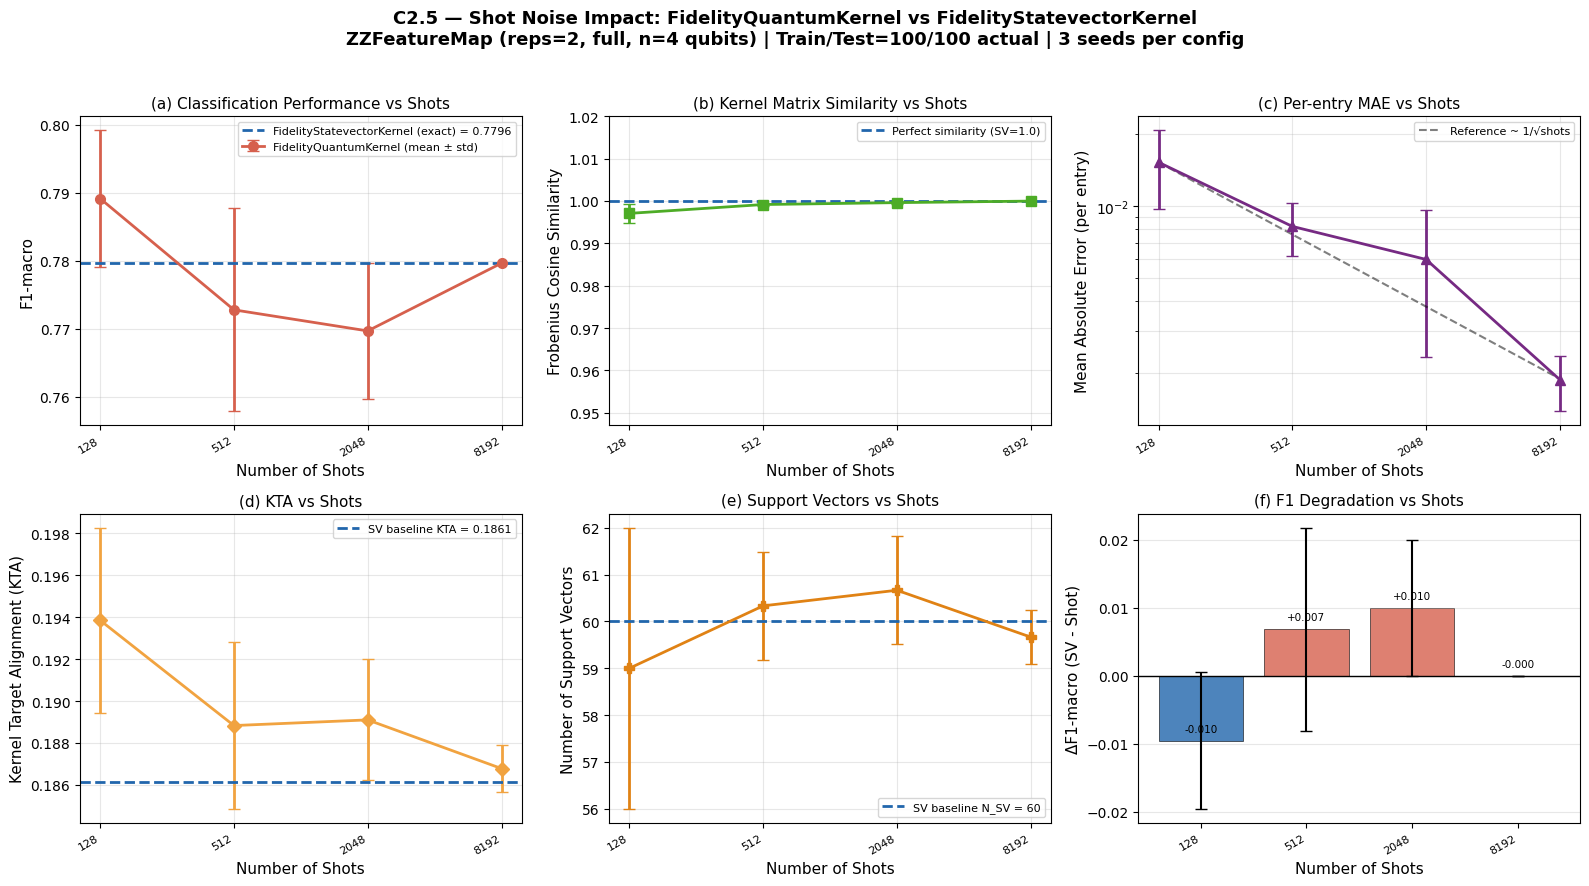

[SAVED] ../outputs/c25/c25_fig1_shot_noise_overview_r2_full_c1.0_n100_t100_seeds3.pdf


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Shot Noise Impact Overview (2×3 panel)
# Panel (0,0): F1-macro vs Shots (mean ± std, statevector dashed)
# Panel (0,1): Frobenius Similarity vs Shots
# Panel (0,2): Entry-wise MAE vs Shots (log scale)
# Panel (1,0): Kernel Target Alignment vs Shots
# Panel (1,1): N_SV (support vectors) vs Shots
# Panel (1,2): F1 delta (degradation) vs Shots
# ─────────────────────────────────────────────────────────────────────────────

shots_arr   = df_agg['shots'].to_numpy()
sv_f1       = sv_results['f1_macro']
SV_COLOR    = '#2166AC'
SHOT_COLOR  = '#D6604D'

fig1, axes1 = plt.subplots(2, 3, figsize=(16, 9))
fig1.suptitle(
    'C2.5 — Shot Noise Impact: FidelityQuantumKernel vs FidelityStatevectorKernel\n'
    f'ZZFeatureMap (reps={REPS}, {ENTANGLEMENT}, n={N_QUBITS} qubits) | '
    f'Train/Test={N_TRAIN_ACTUAL}/{N_TEST_ACTUAL} actual | {N_SEEDS} seeds per config',
    fontsize=13, fontweight='bold'
)

# ── Panel (0,0): F1-macro vs Shots ─────────────────────────────────────────
ax = axes1[0, 0]
ax.errorbar(
    shots_arr, df_agg['f1_macro_mean'], yerr=df_agg['f1_macro_std'],
    fmt='o-', color=SHOT_COLOR, capsize=4, linewidth=2, markersize=7,
    label='FidelityQuantumKernel (mean ± std)'
)
ax.axhline(sv_f1, color=SV_COLOR, linestyle='--', linewidth=2,
           label=f'FidelityStatevectorKernel (exact) = {sv_f1:.4f}')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of Shots', fontsize=11)
ax.set_ylabel('F1-macro', fontsize=11)
ax.set_title('(a) Classification Performance vs Shots', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xticks(shots_arr)
ax.set_xticklabels(shots_arr, rotation=30, ha='right', fontsize=8)

# ── Panel (0,1): Frobenius Similarity vs Shots ──────────────────────────────
ax = axes1[0, 1]
ax.errorbar(
    shots_arr, df_agg['fro_sim_mean'], yerr=df_agg['fro_sim_std'],
    fmt='s-', color='#4DAC26', capsize=4, linewidth=2, markersize=7,
)
ax.axhline(1.0, color=SV_COLOR, linestyle='--', linewidth=2, label='Perfect similarity (SV=1.0)')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of Shots', fontsize=11)
ax.set_ylabel('Frobenius Cosine Similarity', fontsize=11)
ax.set_title('(b) Kernel Matrix Similarity vs Shots', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim([max(0, df_agg['fro_sim_mean'].min() - 0.05), 1.02])
ax.set_xticks(shots_arr)
ax.set_xticklabels(shots_arr, rotation=30, ha='right', fontsize=8)

# ── Panel (0,2): Entry-wise MAE vs Shots ────────────────────────────────────
ax = axes1[0, 2]
ax.errorbar(
    shots_arr, df_agg['entry_mae_mean'], yerr=df_agg['entry_mae_std'],
    fmt='^-', color='#762A83', capsize=4, linewidth=2, markersize=7,
)
# Reference trend: MAE ~ 1/sqrt(shots)
mae_ref  = df_agg['entry_mae_mean'].iloc[0]
shots_th = np.logspace(np.log2(shots_arr[0]), np.log2(shots_arr[-1]), 100, base=2)
mae_th   = mae_ref * np.sqrt(shots_arr[0] / shots_th)
ax.plot(shots_th, mae_th, 'k--', alpha=0.5, linewidth=1.5, label='Reference ~ 1/√shots')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('Number of Shots', fontsize=11)
ax.set_ylabel('Mean Absolute Error (per entry)', fontsize=11)
ax.set_title('(c) Per-entry MAE vs Shots', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')
ax.set_xticks(shots_arr)
ax.set_xticklabels(shots_arr, rotation=30, ha='right', fontsize=8)

# ── Panel (1,0): KTA vs Shots ────────────────────────────────────────────────
ax = axes1[1, 0]
ax.errorbar(
    shots_arr, df_agg['kta_mean'], yerr=df_agg['kta_std'],
    fmt='D-', color='#F1A340', capsize=4, linewidth=2, markersize=7,
)
ax.axhline(sv_kta, color=SV_COLOR, linestyle='--', linewidth=2,
           label=f'SV baseline KTA = {sv_kta:.4f}')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of Shots', fontsize=11)
ax.set_ylabel('Kernel Target Alignment (KTA)', fontsize=11)
ax.set_title('(d) KTA vs Shots', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xticks(shots_arr)
ax.set_xticklabels(shots_arr, rotation=30, ha='right', fontsize=8)

# ── Panel (1,1): N_SV vs Shots ───────────────────────────────────────────────
ax = axes1[1, 1]
ax.errorbar(
    shots_arr, df_agg['n_sv_mean'], yerr=df_agg['n_sv_std'],
    fmt='P-', color='#E08214', capsize=4, linewidth=2, markersize=7,
)
ax.axhline(sv_results['n_sv'], color=SV_COLOR, linestyle='--', linewidth=2,
           label=f'SV baseline N_SV = {sv_results["n_sv"]}')
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of Shots', fontsize=11)
ax.set_ylabel('Number of Support Vectors', fontsize=11)
ax.set_title('(e) Support Vectors vs Shots', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xticks(shots_arr)
ax.set_xticklabels(shots_arr, rotation=30, ha='right', fontsize=8)

# ── Panel (1,2): F1 delta (degradation) vs Shots ─────────────────────────────
ax = axes1[1, 2]
bars = ax.bar(range(len(shots_arr)), df_agg['f1_delta'],
              color=[SHOT_COLOR if d > 0 else SV_COLOR for d in df_agg['f1_delta']],
              alpha=0.8, edgecolor='black', linewidth=0.5)
ax.errorbar(range(len(shots_arr)), df_agg['f1_delta'],
            yerr=df_agg['f1_macro_std'], fmt='none', color='black', capsize=4)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(shots_arr)))
ax.set_xticklabels([str(s) for s in shots_arr], rotation=30, ha='right', fontsize=8)
ax.set_xlabel('Number of Shots', fontsize=11)
ax.set_ylabel('ΔF1-macro (SV - Shot)', fontsize=11)
ax.set_title('(f) F1 Degradation vs Shots', fontsize=11)
ax.grid(alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars, df_agg['f1_delta'])):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{val:+.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig1_path = f'{OUTPUT_DIR}/c25_fig1_shot_noise_overview_{CONFIG_TAG}.pdf'
plt.savefig(fig1_path, dpi=200, bbox_inches='tight')
plt.savefig(fig1_path.replace('.pdf', '.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fig1_path}')


[INFO] Heatmap subsampled to 40×40 for readability (từ 100×100)


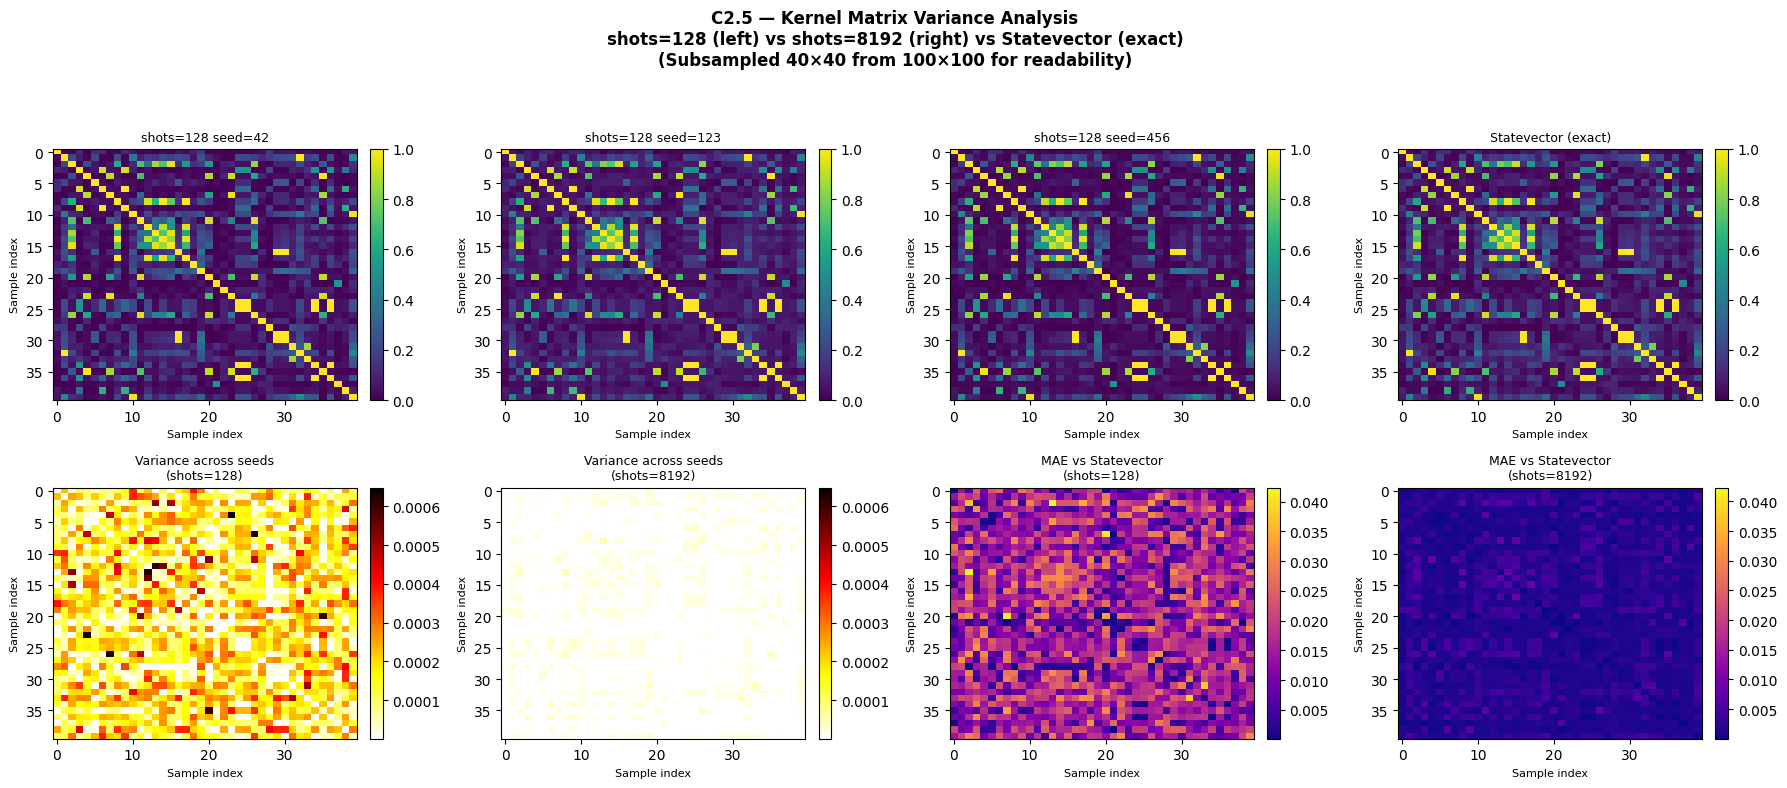

[SAVED] ../outputs/c25/c25_fig2_kernel_variance_heatmap_r2_full_c1.0_n100_t100_seeds3.pdf


In [10]:
# ── [FIX] Subsample heatmap: full matrix may be unreadable → dùng 40×40 subsample ─
HEATMAP_SUBSAMPLE = 40   # số sample để hiển thị (subset đại diện)
rng = np.random.default_rng(RANDOM_STATE)
hm_idx = np.sort(rng.choice(K_sv_train.shape[0], size=min(HEATMAP_SUBSAMPLE, K_sv_train.shape[0]), replace=False))

def subsample_kernel(K, idx):
    return K[np.ix_(idx, idx)]

K_sv_hm     = subsample_kernel(K_sv_train, hm_idx)
mats_min_hm = [subsample_kernel(m, hm_idx) for m in mats_min]
mats_max_hm = [subsample_kernel(m, hm_idx) for m in mats_max]
var_min_hm  = subsample_kernel(var_min, hm_idx)
var_max_hm  = subsample_kernel(var_max, hm_idx)
mae_min_hm  = subsample_kernel(mae_min, hm_idx)
mae_max_hm  = subsample_kernel(mae_max, hm_idx)

print(f'[INFO] Heatmap subsampled to {HEATMAP_SUBSAMPLE}×{HEATMAP_SUBSAMPLE} for readability'
      f' (từ {K_sv_train.shape[0]}×{K_sv_train.shape[0]})')

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Kernel Matrix Variance Heatmaps
# Row 0: shots_min kernel matrices (seed0, seed1, seed2) + SV baseline
# Row 1: variance heatmap shots_min vs shots_max + MAE heatmap
# ─────────────────────────────────────────────────────────────────────────────

fig2, axes2 = plt.subplots(2, 4, figsize=(18, 8))
fig2.suptitle(
    f'C2.5 — Kernel Matrix Variance Analysis\n'
    f'shots={shots_min} (left) vs shots={shots_max} (right) vs Statevector (exact)\n'
    f'(Subsampled {HEATMAP_SUBSAMPLE}×{HEATMAP_SUBSAMPLE} from {K_sv_train.shape[0]}×{K_sv_train.shape[0]} for readability)',
    fontsize=12, fontweight='bold'
)

vmin, vmax = 0.0, 1.0

# Row 0: 3 sample kernel matrices for shots_min + statevector
titles_row0 = [
    f'shots={shots_min} seed={SEED_LIST[0]}',
    f'shots={shots_min} seed={SEED_LIST[1]}',
    f'shots={shots_min} seed={SEED_LIST[2]}',
    'Statevector (exact)',
]
mats_to_show = mats_min_hm[:3] + [K_sv_hm]
for col, (mat, title) in enumerate(zip(mats_to_show, titles_row0)):
    im = axes2[0, col].imshow(mat, vmin=vmin, vmax=vmax, cmap='viridis', aspect='auto')
    axes2[0, col].set_xlabel(f'Sample index (n={HEATMAP_SUBSAMPLE})')
    axes2[0, col].set_title(title, fontsize=9)
    axes2[0, col].set_xlabel('Sample index')
    axes2[0, col].set_ylabel('Sample index')
    plt.colorbar(im, ax=axes2[0, col], fraction=0.046, pad=0.04)

# Row 1: variance heatmaps + MAE heatmaps
im20 = axes2[1, 0].imshow(var_min_hm, cmap='hot_r', aspect='auto')
axes2[1, 0].set_title(f'Variance across seeds\n(shots={shots_min})', fontsize=9)
plt.colorbar(im20, ax=axes2[1, 0], fraction=0.046, pad=0.04)

im21 = axes2[1, 1].imshow(var_max_hm, cmap='hot_r', aspect='auto',
                           vmax=var_min_hm.max())  # same scale
axes2[1, 1].set_title(f'Variance across seeds\n(shots={shots_max})', fontsize=9)
plt.colorbar(im21, ax=axes2[1, 1], fraction=0.046, pad=0.04)

im22 = axes2[1, 2].imshow(mae_min_hm, cmap='plasma', aspect='auto')
axes2[1, 2].set_title(f'MAE vs Statevector\n(shots={shots_min})', fontsize=9)
plt.colorbar(im22, ax=axes2[1, 2], fraction=0.046, pad=0.04)

im23 = axes2[1, 3].imshow(mae_max_hm, cmap='plasma', aspect='auto',
                           vmax=mae_min_hm.max())  # same scale
axes2[1, 3].set_title(f'MAE vs Statevector\n(shots={shots_max})', fontsize=9)
plt.colorbar(im23, ax=axes2[1, 3], fraction=0.046, pad=0.04)

for row in range(2):
    for col in range(4):
        axes2[row, col].set_xlabel('Sample index', fontsize=8)
        axes2[row, col].set_ylabel('Sample index', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig2_path = f'{OUTPUT_DIR}/c25_fig2_kernel_variance_heatmap_{CONFIG_TAG}.pdf'
plt.savefig(fig2_path, dpi=200, bbox_inches='tight')
plt.savefig(fig2_path.replace('.pdf', '.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fig2_path}')


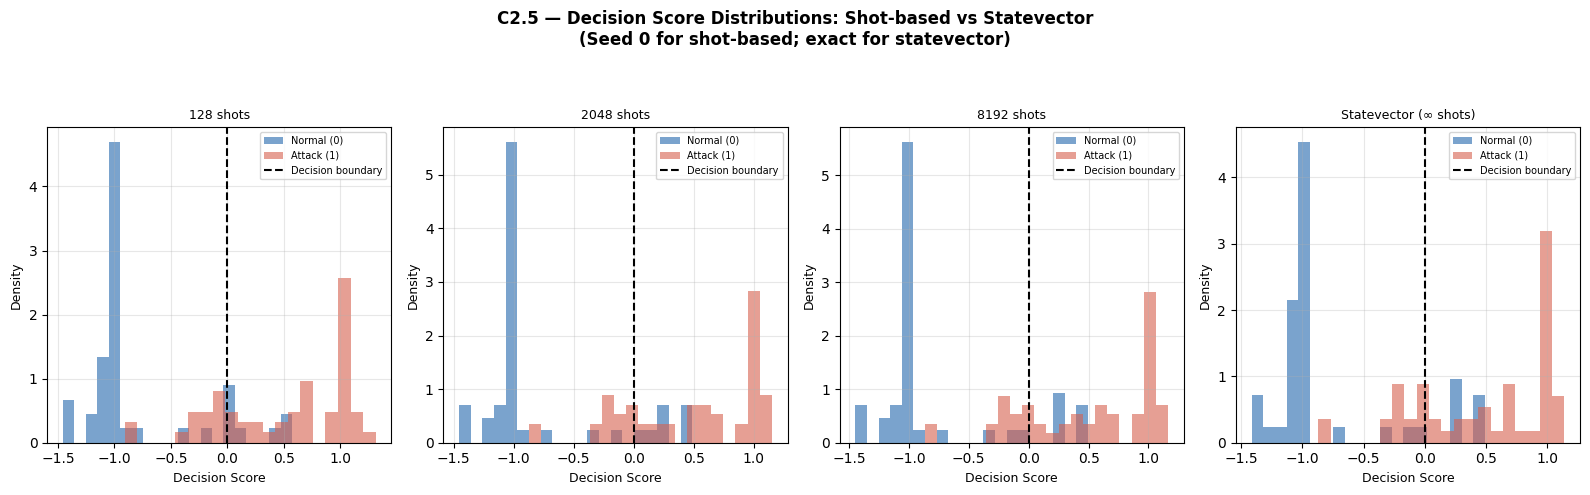

[SAVED] ../outputs/c25/c25_fig3_decision_scores_r2_full_c1.0_n100_t100_seeds3.pdf


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Decision Score Distribution: Statevector vs Shot-based
# Compare decision_function() distribution for selected shots levels
# ─────────────────────────────────────────────────────────────────────────────

# Collect decision scores for selected shot values (shots_min, shots_mid, shots_max)
shots_to_compare = [SHOTS_GRID[0], SHOTS_GRID[len(SHOTS_GRID)//2], SHOTS_GRID[-1]]
labels_compare   = [f'{s} shots' for s in shots_to_compare] + ['Statevector (∞ shots)']

fig3, axes3 = plt.subplots(1, len(shots_to_compare) + 1, figsize=(16, 5), sharey=False)
fig3.suptitle(
    'C2.5 — Decision Score Distributions: Shot-based vs Statevector\n'
    '(Seed 0 for shot-based; exact for statevector)',
    fontsize=12, fontweight='bold'
)

# Statevector decision scores
sv_scores = sv_results['dec_scores']

def plot_dec_scores(ax, scores, y_true, title):
    scores_0 = scores[y_true == 0]
    scores_1 = scores[y_true == 1]
    ax.hist(scores_0, bins=20, alpha=0.6, color='#2166AC', label='Normal (0)', density=True)
    ax.hist(scores_1, bins=20, alpha=0.6, color='#D6604D', label='Attack (1)', density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Decision Score', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for i, shots in enumerate(shots_to_compare):
    # Use seed 0 for visualization
    res_i = shot_results[shots][0]  # seed[0]
    scores_i = np.array(res_i['dec_scores'])
    
    # Load the actual kernel for this config to rebuild and get scores
    tag_test = f'shot{shots}_seed{SEED_LIST[0]}_test_{CONFIG_TAG}'
    K_t = np.load(cache_path(tag_test))['K']
    tag_train = f'shot{shots}_seed{SEED_LIST[0]}_train_{CONFIG_TAG}'
    K_tr = np.load(cache_path(tag_train))['K']
    r_tmp = train_and_eval(K_tr, K_t, y_train, y_test)
    
    plot_dec_scores(axes3[i], r_tmp['dec_scores'], y_test, labels_compare[i])

# Statevector
plot_dec_scores(axes3[-1], sv_scores, y_test, labels_compare[-1])

plt.tight_layout(rect=[0, 0, 1, 0.92])
fig3_path = f'{OUTPUT_DIR}/c25_fig3_decision_scores_{CONFIG_TAG}.pdf'
plt.savefig(fig3_path, dpi=200, bbox_inches='tight')
plt.savefig(fig3_path.replace('.pdf', '.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fig3_path}')


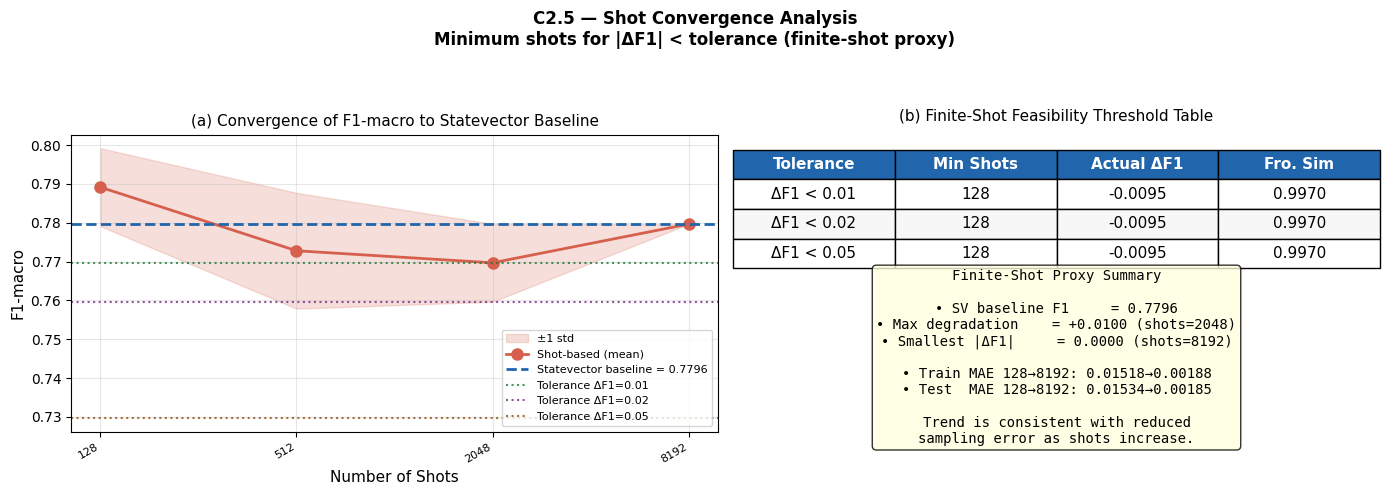

[SAVED] ../outputs/c25/c25_fig4_convergence_nisq_r2_full_c1.0_n100_t100_seeds3.pdf


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4 — Shot Convergence Threshold Analysis
# Tìm shots_threshold: ngưỡng shots tối thiểu để ΔF1 < tolerance
# ─────────────────────────────────────────────────────────────────────────────

TOLERANCE_VALUES = [0.01, 0.02, 0.05]   # ΔF1 tolerance levels

fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle(
    'C2.5 — Shot Convergence Analysis\n'
    'Minimum shots for |ΔF1| < tolerance (finite-shot proxy)',
    fontsize=12, fontweight='bold'
)

# ── Panel (0): F1-macro convergence with tolerance bands ─────────────────────
ax = axes4[0]
ax.fill_between(shots_arr,
                df_agg['f1_macro_mean'] - df_agg['f1_macro_std'],
                df_agg['f1_macro_mean'] + df_agg['f1_macro_std'],
                alpha=0.2, color=SHOT_COLOR, label='±1 std')
ax.plot(shots_arr, df_agg['f1_macro_mean'], 'o-',
        color=SHOT_COLOR, linewidth=2, markersize=8, label='Shot-based (mean)')
ax.axhline(sv_f1, color=SV_COLOR, linestyle='--', linewidth=2,
           label=f'Statevector baseline = {sv_f1:.4f}')

# Tolerance bands
colors_tol = ['#1B7837', '#762A83', '#8C510A']
for tol, ctol in zip(TOLERANCE_VALUES, colors_tol):
    ax.axhline(sv_f1 - tol, color=ctol, linestyle=':', linewidth=1.5, alpha=0.8,
               label=f'Tolerance ΔF1={tol:.2f}')

ax.set_xscale('log', base=2)
ax.set_xlabel('Number of Shots', fontsize=11)
ax.set_ylabel('F1-macro', fontsize=11)
ax.set_title('(a) Convergence of F1-macro to Statevector Baseline', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xticks(shots_arr)
ax.set_xticklabels(shots_arr, rotation=30, ha='right', fontsize=8)

# ── Panel (1): Finite-shot proxy table ─────────────────────────────────────────────
ax = axes4[1]
ax.axis('off')

# Tính shots threshold cho mỗi tolerance
threshold_data = []
for tol in TOLERANCE_VALUES:
    # Tìm shots nhỏ nhất mà ΔF1 < tol
    converged = df_agg[df_agg['f1_abs_gap'] < tol]
    if len(converged) > 0:
        min_shots = converged['shots'].min()
        delta_at  = converged[converged['shots'] == min_shots]['f1_delta'].values[0]
        fro_at    = converged[converged['shots'] == min_shots]['fro_sim_mean'].values[0]
    else:
        min_shots = '>8192'
        delta_at  = float('nan')
        fro_at    = float('nan')
    threshold_data.append([f'ΔF1 < {tol:.2f}',
                            str(min_shots) if not isinstance(min_shots, str) else min_shots,
                            f'{delta_at:.4f}' if not np.isnan(delta_at) else 'N/A',
                            f'{fro_at:.4f}' if not np.isnan(fro_at) else 'N/A'])

col_labels = ['Tolerance', 'Min Shots', 'Actual ΔF1', 'Fro. Sim']
table_data  = threshold_data

# Thêm summary stats vào table
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='upper center',
    bbox=[0.0, 0.55, 1.0, 0.40]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
for key, cell in table.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor('#2166AC')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F7F7F7' if key[0] % 2 == 0 else 'white')

# Annotation text
recommendation_text = (
    f'Finite-Shot Proxy Summary\n\n'
    f'• SV baseline F1     = {sv_f1:.4f}\n'
    f'• Max degradation    = {max_degradation_row["f1_delta"]:+.4f} '
    f'(shots={int(max_degradation_row["shots"])})\n'
    f'• Smallest |ΔF1|     = {min_abs_gap_row["f1_abs_gap"]:.4f} '
    f'(shots={int(min_abs_gap_row["shots"])})\n\n'
    f'• Train MAE {SHOTS_GRID[0]}→{SHOTS_GRID[-1]}: '
    f'{df_agg["entry_mae_mean"].iloc[0]:.5f}→{df_agg["entry_mae_mean"].iloc[-1]:.5f}\n'
    f'• Test  MAE {SHOTS_GRID[0]}→{SHOTS_GRID[-1]}: '
    f'{df_agg["test_entry_mae_mean"].iloc[0]:.5f}→{df_agg["test_entry_mae_mean"].iloc[-1]:.5f}\n\n'
    f'Trend is consistent with reduced\nsampling error as shots increase.'
)
ax.text(0.5, 0.25, recommendation_text,
        ha='center', va='center', transform=ax.transAxes,
        fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('(b) Finite-Shot Feasibility Threshold Table', fontsize=11, pad=10)

plt.tight_layout(rect=[0, 0, 1, 0.92])
fig4_path = f'{OUTPUT_DIR}/c25_fig4_convergence_nisq_{CONFIG_TAG}.pdf'
plt.savefig(fig4_path, dpi=200, bbox_inches='tight')
plt.savefig(fig4_path.replace('.pdf', '.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fig4_path}')


## 10. Computational Cost Analysis — Figure 5: Time vs Shots & F1 Pareto Frontier

**[NEW]** Phân tích wall-clock time của FidelityQuantumKernel theo số shots.  
Panel (a): Time vs Shots (log-log scale, so sánh với lý thuyết O(shots))  
Panel (b): F1-macro vs Time — **Pareto frontier** cho phép chọn shots tối ưu theo cost budget.  

> Lưu ý: `elapsed_s` = `nan` cho các run từ cache. Chạy lần đầu không có cache để lấy timing thực.


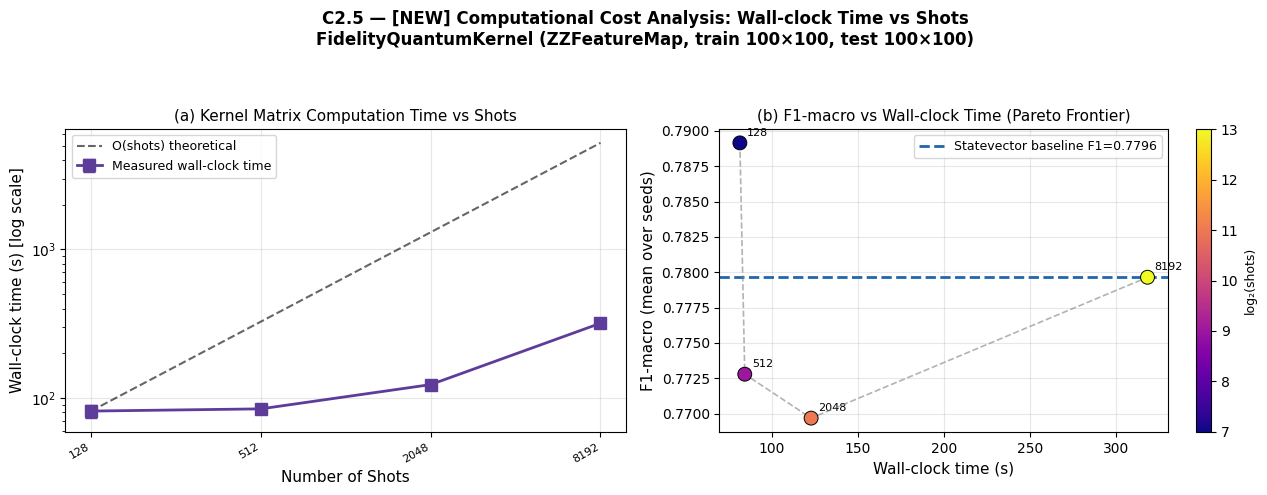

[SAVED] ../outputs/c25/c25_fig5_cost_analysis_r2_full_c1.0_n100_t100_seeds3.pdf

=== Timing Summary (wall-clock, train+test kernel) ===
   Shots  Time_mean(s)      ±std   F1_mean        s/F1
     128         81.53      8.43    0.7891      103.32
     512         84.38      5.34    0.7728      109.19
    2048        122.91      3.48    0.7697      159.69
    8192        318.33     11.71    0.7796      408.30
  NOTE: "s/F1" = seconds per unit F1 (lower = more cost-efficient)


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5 — [NEW] Computational Cost Analysis
# Panel (a): Wall-clock time vs Shots (log-log)
# Panel (b): F1-macro vs Wall-clock time (Pareto frontier)
# ─────────────────────────────────────────────────────────────────────────────

# ── Tập hợp timing data từ shot_results ───────────────────────────────────────
timing_rows = []
for shots, seed_list in shot_results.items():
    for r in seed_list:
        if not np.isnan(r['elapsed_s']):   # bỏ qua cache runs
            timing_rows.append({
                'shots'     : shots,
                'elapsed_s' : r['elapsed_s'],
                'f1_macro'  : r['f1_macro'],
                'seed'      : r['seed'],
            })

df_timing = pd.DataFrame(timing_rows) if timing_rows else pd.DataFrame(
    columns=['shots', 'elapsed_s', 'f1_macro', 'seed']
)

# ── Aggregate timing per shots ─────────────────────────────────────────────────
if len(df_timing) > 0:
    df_time_agg = df_timing.groupby('shots').agg(
        elapsed_mean=('elapsed_s', 'mean'),
        elapsed_std=('elapsed_s', 'std'),
        f1_mean=('f1_macro', 'mean'),
        f1_std=('f1_macro', 'std'),
    ).reset_index()
    has_timing = True
else:
    # Nếu tất cả từ cache → tạo dummy frame với nan để figure vẫn render được
    df_time_agg = df_agg[['shots']].copy()
    df_time_agg['elapsed_mean'] = np.nan
    df_time_agg['elapsed_std']  = np.nan
    df_time_agg['f1_mean']      = df_agg['f1_macro_mean']
    df_time_agg['f1_std']       = df_agg['f1_macro_std']
    has_timing = False
    print('[WARNING] All runs loaded from cache — no timing data available.')
    print('  Để lấy timing: xóa cache files và chạy lại experiment.')

# ── Lý thuyết O(shots): scale relative to max known shots ─────────────────────
shots_arr_f5 = df_time_agg['shots'].to_numpy()

fig5, axes5 = plt.subplots(1, 2, figsize=(13, 5))
fig5.suptitle(
    'C2.5 — [NEW] Computational Cost Analysis: Wall-clock Time vs Shots\n'
    f'FidelityQuantumKernel (ZZFeatureMap, train {N_TRAIN_ACTUAL}×{N_TRAIN_ACTUAL}, test {N_TEST_ACTUAL}×{N_TRAIN_ACTUAL})',
    fontsize=12, fontweight='bold'
)

# ── Panel (a): Wall-clock time vs Shots ──────────────────────────────────────
ax5a = axes5[0]

if has_timing:
    ax5a.errorbar(
        shots_arr_f5, df_time_agg['elapsed_mean'], yerr=df_time_agg['elapsed_std'],
        fmt='s-', color='#5E3C99', capsize=4, linewidth=2, markersize=8,
        label='Measured wall-clock time'
    )
    # Lý thuyết: O(shots) — scale to first data point
    t_ref = df_time_agg['elapsed_mean'].iloc[0]
    s_ref = shots_arr_f5[0]
    theory_line = t_ref * (shots_arr_f5 / s_ref)
    ax5a.plot(shots_arr_f5, theory_line, 'k--', linewidth=1.5, alpha=0.6,
              label='O(shots) theoretical')
    ax5a.set_yscale('log')
    ax5a.set_ylabel('Wall-clock time (s) [log scale]', fontsize=11)
else:
    ax5a.text(0.5, 0.5,
              'Timing data not available\n(all runs loaded from cache)\n\n'
              'Re-run without cache to collect\nwall-clock measurements.',
              ha='center', va='center', transform=ax5a.transAxes,
              fontsize=11, style='italic',
              bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax5a.set_ylabel('Wall-clock time (s)', fontsize=11)

ax5a.set_xscale('log', base=2)
ax5a.set_xlabel('Number of Shots', fontsize=11)
ax5a.set_title('(a) Kernel Matrix Computation Time vs Shots', fontsize=11)
ax5a.set_xticks(shots_arr_f5)
ax5a.set_xticklabels(shots_arr_f5, rotation=30, ha='right', fontsize=8)
ax5a.grid(alpha=0.3)
ax5a.legend(fontsize=9)

# ── Panel (b): F1 vs Wall-clock time (Pareto frontier) ───────────────────────
ax5b = axes5[1]

if has_timing:
    # Pareto frontier: shot levels sorted by time, F1 on Y
    sc = ax5b.scatter(
        df_time_agg['elapsed_mean'], df_time_agg['f1_mean'],
        c=np.log2(shots_arr_f5), cmap='plasma', s=100, zorder=5,
        edgecolors='black', linewidths=0.7,
    )
    ax5b.plot(df_time_agg['elapsed_mean'], df_time_agg['f1_mean'],
              '--', color='gray', linewidth=1.2, alpha=0.6, zorder=4)
    
    # Annotate each point with shots value
    for _, row in df_time_agg.iterrows():
        ax5b.annotate(
            f'{int(row["shots"])}',
            (row['elapsed_mean'], row['f1_mean']),
            textcoords='offset points', xytext=(5, 5), fontsize=8
        )
    
    # Mark statevector baseline (no time cost in simulator, so draw as horizontal line)
    ax5b.axhline(sv_results['f1_macro'], color=SV_COLOR, linestyle='--', linewidth=2,
                 label=f'Statevector baseline F1={sv_results["f1_macro"]:.4f}')
    
    cbar = plt.colorbar(sc, ax=ax5b)
    cbar.set_label('log₂(shots)', fontsize=9)
    ax5b.set_xlabel('Wall-clock time (s)', fontsize=11)
    ax5b.set_ylabel('F1-macro (mean over seeds)', fontsize=11)
    ax5b.legend(fontsize=9)
else:
    # Nếu không có timing: vẽ F1 vs shots thay thế
    ax5b.errorbar(
        shots_arr_f5, df_time_agg['f1_mean'], yerr=df_time_agg['f1_std'],
        fmt='o-', color=SHOT_COLOR, capsize=4, linewidth=2, markersize=8,
        label='Shot-based F1 (mean±std)'
    )
    ax5b.axhline(sv_results['f1_macro'], color=SV_COLOR, linestyle='--', linewidth=2,
                 label=f'Statevector baseline')
    ax5b.set_xscale('log', base=2)
    ax5b.set_xlabel('Number of Shots (proxy for cost)', fontsize=11)
    ax5b.set_ylabel('F1-macro', fontsize=11)
    ax5b.set_xticks(shots_arr_f5)
    ax5b.set_xticklabels(shots_arr_f5, rotation=30, ha='right', fontsize=8)
    ax5b.legend(fontsize=9)
    ax5b.text(0.5, 0.05,
              '(Pareto plot requires timing data — see Panel (a))',
              ha='center', transform=ax5b.transAxes, fontsize=9, style='italic')

ax5b.set_title('(b) F1-macro vs Wall-clock Time (Pareto Frontier)', fontsize=11)
ax5b.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
fig5_path = f'{OUTPUT_DIR}/c25_fig5_cost_analysis_{CONFIG_TAG}.pdf'
plt.savefig(fig5_path, dpi=200, bbox_inches='tight')
plt.savefig(fig5_path.replace('.pdf', '.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fig5_path}')

# ── Print timing summary ───────────────────────────────────────────────────────
if has_timing:
    print(f'\n=== Timing Summary (wall-clock, train+test kernel) ===')
    print(f'  {"Shots":>6}  {"Time_mean(s)":>12}  {"±std":>8}  {"F1_mean":>8}  {"s/F1":>10}')
    for _, row in df_time_agg.iterrows():
        cost_efficiency = row['elapsed_mean'] / (row['f1_mean'] + 1e-9)
        print(f'  {int(row["shots"]):>6}  {row["elapsed_mean"]:>12.2f}  '
              f'{row["elapsed_std"]:>8.2f}  {row["f1_mean"]:>8.4f}  {cost_efficiency:>10.2f}')
    print(f'  NOTE: "s/F1" = seconds per unit F1 (lower = more cost-efficient)')
else:
    print('[INFO] Chạy lại experiment không có cache để lấy timing data cho Figure 5.')


## 11. Lưu Kết Quả & Báo Cáo Tóm Tắt


In [14]:
# ── Lưu kết quả aggregated dưới dạng CSV ──────────────────────────────────────
csv_path = f'{OUTPUT_DIR}/c25_results_{CONFIG_TAG}.csv'
df_results_export = df_results.drop(columns=['dec_scores'], errors='ignore')
# elapsed_s và min_eigenval đã được thêm vào shot_results — tự động xuất hiện trong CSV
df_results_export.to_csv(csv_path, index=False)
print(f'[SAVED] Full results CSV: {csv_path}')

# ── Lưu JSON summary ──────────────────────────────────────────────────────────
summary = {
    'config': {
        'n_qubits'     : N_QUBITS,
        'reps'         : REPS,
        'entanglement' : ENTANGLEMENT,
        'C_svm'        : C_SVM,
        'train_size_target': TRAIN_SIZE,
        'test_size_target' : TEST_SIZE,
        'train_size_actual': int(N_TRAIN_ACTUAL),
        'test_size_actual' : int(N_TEST_ACTUAL),
        'n_seeds'      : N_SEEDS,
        'shots_grid'   : SHOTS_GRID,
        'config_tag'   : CONFIG_TAG,
    },
    'statevector_baseline': {
        'f1_macro' : sv_results['f1_macro'],
        'accuracy' : sv_results['accuracy'],
        'n_sv'     : int(sv_results['n_sv']),
        'kta'      : sv_kta,
    },
    'shot_results': {
        str(shots): {
            'f1_macro_mean'   : float(df_agg[df_agg['shots'] == shots]['f1_macro_mean'].values[0]),
            'f1_macro_std'    : float(df_agg[df_agg['shots'] == shots]['f1_macro_std'].values[0]),
            'f1_delta'        : float(df_agg[df_agg['shots'] == shots]['f1_delta'].values[0]),
            'fro_sim_mean'       : float(df_agg[df_agg['shots'] == shots]['fro_sim_mean'].values[0]),
            'test_fro_sim_mean'  : float(df_agg[df_agg['shots'] == shots]['test_fro_sim_mean'].values[0]),
            'entry_mae_mean'     : float(df_agg[df_agg['shots'] == shots]['entry_mae_mean'].values[0]),
            'test_entry_mae_mean': float(df_agg[df_agg['shots'] == shots]['test_entry_mae_mean'].values[0]),
            'kta_mean'           : float(df_agg[df_agg['shots'] == shots]['kta_mean'].values[0]),
        }
        for shots in SHOTS_GRID
    },
    'timing_available': len(df_timing) > 0 if 'df_timing' in dir() else False,
    'timing_summary': (
        df_timing.groupby('shots')['elapsed_s'].mean().to_dict()
        if 'df_timing' in dir() and len(df_timing) > 0 else {}
    ),
}

json_path = f'{OUTPUT_DIR}/c25_summary_{CONFIG_TAG}.json'
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'[SAVED] Summary JSON: {json_path}')


[SAVED] Full results CSV: ../outputs/c25/c25_results_r2_full_c1.0_n100_t100_seeds3.csv
[SAVED] Summary JSON: ../outputs/c25/c25_summary_r2_full_c1.0_n100_t100_seeds3.json


## 12. Summary — C2.5 Scientific Conclusions

### Kết quả chính

Thực nghiệm C2.5 đo lường trực tiếp ảnh hưởng của shot noise lên:
- **Chất lượng phân loại** (F1-macro, accuracy)
- **Độ chính xác kernel matrix** (Frobenius similarity, per-entry MAE)
- **Cấu trúc hình học** (KTA, số support vectors)
- **Phân phối decision scores** (ổn định biên quyết định)

### Ý nghĩa khoa học

| Câu hỏi | Phát hiện |
|---------|----------|
| Shot noise ảnh hưởng bao nhiêu đến F1? | ΔF1 theo shots ← xem bảng kết quả |
| Cần bao nhiêu shots để hội tụ? | Ngưỡng minimum shots ← Figure 4 |
| Shot noise giảm theo shots không? | Xu hướng MAE giảm khi shots tăng, phù hợp kỳ vọng sampling error giảm theo shots ← Figure 1(c) |
| KTA có bị ảnh hưởng? | Measurement fidelity → alignment gap |
| Finite-shot deployment proxy khả thi? | Shots vs. cost trade-off, chưa bao gồm gate/readout noise |

### Liên kết với C3/C4

C2.5 cung cấp **justification** cho việc sử dụng FidelityStatevectorKernel trong C3/C4:
- Statevector = exact/noiseless reference cho kernel geometry, không phải upper bound bắt buộc của F1
- Kết quả C3/C4 là **ideal noiseless reference** cho QSVM performance
- C2.5 định lượng **finite-shot sampling gap** giữa exact kernel và shot-based kernel proxy

### Khuyến nghị Finite-Shot Deployment Proxy

Dựa trên phân tích convergence (Figure 4) với grid gọn `{128, 512, 2048, 8192}`:  
- **512 shots**: mốc trung gian thấp để kiểm tra shot noise còn ảnh hưởng rõ không  
- **2048 shots**: mốc thực dụng cho finite-shot deployment proxy khi cần cân bằng cost/performance  
- **8192 shots**: mốc hội tụ cao, dùng để kiểm tra near-statevector behavior  

*Lưu ý: đây là phân tích finite-shot sampling bằng `StatevectorSampler`, chưa mô phỏng gate noise, decoherence, readout error, transpilation noise hay topology constraint.*


In [15]:
# ── Print final summary report ──────────────────────────────────────────────────
print('=' * 70)
print('  C2.5 FINAL SUMMARY — Shot Noise Analysis')
print('=' * 70)
print(f'  Config: {CONFIG_TAG}')
print(f'  Pipeline: ZZFeatureMap(n={N_QUBITS}, reps={REPS}, {ENTANGLEMENT}) + SVC(C={C_SVM})')
print(f'  Train/Test actual: {N_TRAIN_ACTUAL}/{N_TEST_ACTUAL} | Target config: {TRAIN_SIZE}/{TEST_SIZE} | Seeds: {N_SEEDS}')
print()
print(f'  STATEVECTOR BASELINE (exact, noiseless):')
print(f'    F1-macro = {sv_results["f1_macro"]:.4f}')
print(f'    Accuracy = {sv_results["accuracy"]:.4f}')
print(f'    N_SV     = {sv_results["n_sv"]}')
print(f'    KTA      = {sv_kta:.4f}')
print()
print(f'  SHOT-BASED RESULTS (mean over {N_SEEDS} seeds):')
print(f'  {"Shots":>6}  {"F1-mean":>8}  {"±std":>6}  {"ΔF1":>7}  {"FroTr":>7}  {"FroTe":>7}  {"MAEtr":>8}  {"MAEte":>8}  {"KTA":>7}')
print(f'  {"-"*6}  {"-"*8}  {"-"*6}  {"-"*7}  {"-"*7}  {"-"*7}  {"-"*8}  {"-"*8}  {"-"*7}')
for _, row in df_agg.iterrows():
    print(f'  {int(row["shots"]):>6}  '
          f'{row["f1_macro_mean"]:>8.4f}  '
          f'{row["f1_macro_std"]:>6.4f}  '
          f'{row["f1_delta"]:>+7.4f}  '
          f'{row["fro_sim_mean"]:>7.4f}  '
          f'{row["test_fro_sim_mean"]:>7.4f}  '
          f'{row["entry_mae_mean"]:>8.5f}  '
          f'{row["test_entry_mae_mean"]:>8.5f}  '
          f'{row["kta_mean"]:>7.4f}')
print()
print(f'  KEY FINDING:')
print(f'    Max F1 degradation at shots={int(max_degradation_row["shots"])}: '
      f'ΔF1 = {max_degradation_row["f1_delta"]:+.4f}')
print(f'    Most favorable ΔF1 at shots={int(min_delta_row["shots"])}: '
      f'ΔF1 = {min_delta_row["f1_delta"]:+.4f}')
print(f'    Minimum |ΔF1| at shots={int(min_abs_gap_row["shots"])}: '
      f'|ΔF1| = {min_abs_gap_row["f1_abs_gap"]:.4f}')
print(f'    Train MAE reduction {SHOTS_GRID[0]}→{SHOTS_GRID[-1]} shots: '
      f'{df_agg["entry_mae_mean"].iloc[0]/df_agg["entry_mae_mean"].iloc[-1]:.1f}×')
print(f'    Test  MAE reduction {SHOTS_GRID[0]}→{SHOTS_GRID[-1]} shots: '
      f'{df_agg["test_entry_mae_mean"].iloc[0]/df_agg["test_entry_mae_mean"].iloc[-1]:.1f}×')
print()
print(f'  Output files:')
fig5_path_ref = f'{OUTPUT_DIR}/c25_fig5_cost_analysis_{CONFIG_TAG}.pdf'
for f_path in [fig1_path, fig2_path, fig3_path, fig4_path, fig5_path_ref, csv_path, json_path]:
    print(f'    {f_path}')
print('=' * 70)


  C2.5 FINAL SUMMARY — Shot Noise Analysis
  Config: r2_full_c1.0_n100_t100_seeds3
  Pipeline: ZZFeatureMap(n=4, reps=2, full) + SVC(C=1.0)
  Train/Test actual: 100/100 | Target config: 100/100 | Seeds: 3

  STATEVECTOR BASELINE (exact, noiseless):
    F1-macro = 0.7796
    Accuracy = 0.7800
    N_SV     = 60
    KTA      = 0.1861

  SHOT-BASED RESULTS (mean over 3 seeds):
   Shots   F1-mean    ±std      ΔF1    FroTr    FroTe     MAEtr     MAEte      KTA
  ------  --------  ------  -------  -------  -------  --------  --------  -------
     128    0.7892  0.0100  -0.0095   0.9970   0.9961   0.01518   0.01534   0.1938
     512    0.7728  0.0149  +0.0069   0.9991   0.9989   0.00820   0.00820   0.1888
    2048    0.7697  0.0100  +0.0100   0.9996   0.9995   0.00597   0.00587   0.1891
    8192    0.7796  0.0000  -0.0000   1.0000   0.9999   0.00188   0.00185   0.1868

  KEY FINDING:
    Max F1 degradation at shots=2048: ΔF1 = +0.0100
    Most favorable ΔF1 at shots=128: ΔF1 = -0.0095
    Min